# FlashSpec Colab A100 Profiling Runbook

In Colab, select `Runtime -> Change runtime type -> GPU`. For formal profiling, prefer A100.

Recommended order:

1. Mount Drive, verify GPU, install the project and Triton.
2. Check `ncu`, then run correctness tests.
3. Run one sanity profiling pass to verify `measured_*` fields are populated.
4. The historical full matrix is already done; rerun matrix profiling only for reproduction or missing points.
5. Based on `doc/optimization-log.md`, the next step is focused source-line / instruction attribution on a few points.
6. Save `.ncu-rep` files and use them to update `optimization-log.md`.

Default project directory: `/content/drive/MyDrive/FlashSpecColab`. Results are written to `results/colab_kernels/`, `results/profile_matrix/`, and `results/ncu_source_attribution/`.

## 0. 挂载 Google Drive 并设置路径

结果会直接写到你的 Drive，避免 Colab runtime 重启后丢失。

In [1]:
from google.colab import drive
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/FlashSpecColab')
COLAB_RESULTS_DIR = PROJECT_DIR / 'results' / 'colab_kernels'
MATRIX_RESULTS_DIR = PROJECT_DIR / 'results' / 'profile_matrix'

drive.mount('/content/drive')
COLAB_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MATRIX_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR:', PROJECT_DIR)
print('COLAB_RESULTS_DIR:', COLAB_RESULTS_DIR)
print('MATRIX_RESULTS_DIR:', MATRIX_RESULTS_DIR)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/FlashSpecColab
COLAB_RESULTS_DIR: /content/drive/MyDrive/FlashSpecColab/results/colab_kernels
MATRIX_RESULTS_DIR: /content/drive/MyDrive/FlashSpecColab/results/profile_matrix


## 1. 检查 GPU 环境

这里应该看到 `cuda available=True`。如果不是 A100，也可以先跑 correctness 和小规模 sanity，但 profiling 结果不要和 A100 结果直接比较。

In [2]:
import torch

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))
else:
    raise RuntimeError('当前 Colab runtime 没有 CUDA GPU，请切换到 GPU/A100 runtime。')

torch: 2.11.0+cu128
cuda available: True
gpu: NVIDIA A100-SXM4-40GB


## 2. 克隆或更新项目

如果 Drive 里已经有仓库，会执行 `git pull --ff-only`。如果你在 notebook 里改了代码，先把改动提交或推送后再运行这一格。

In [3]:
import os
import subprocess
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/FlashSpecColab')

if (PROJECT_DIR / '.git').exists():
    subprocess.run(['git', '-C', str(PROJECT_DIR), 'pull', '--ff-only'], check=True)
elif not PROJECT_DIR.exists():
    subprocess.run(
        ['git', 'clone', 'https://github.com/honey-floria/FlashSpec.git', str(PROJECT_DIR)],
        check=True,
    )
else:
    raise RuntimeError(
        f'{PROJECT_DIR} 已存在但不是 Git 仓库，请改名或删除后重新 clone FlashSpec。'
    )

os.chdir(PROJECT_DIR)
print('cwd:', Path.cwd())
%pip install -e '.[triton]'

cwd: /content/drive/MyDrive/FlashSpecColab
Obtaining file:///content/drive/MyDrive/FlashSpecColab
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for flashspec (pyproject.toml) ... done
  Created wheel for flashspec: filename=flashspec-0.1.0-0.editable-py3-none-any.whl size=5539 sha256=ba455782d36c9e93c13fb47986e06ec15a68d8b0a19345ee3848710a74f523ae
  Stored in directory: /tmp/pip-ephem-wheel-cache-vq0bgr6y/wheels/20/f3/31/42cb6f1ef3c76c71000d8ea03a1ac3fb33b5e04a80e8e3a84c
Successfully built flashspec


## 3. 检查 FlashSpec、CUDA、Triton 和 ncu

`HAS_TRITON=True` 才能跑 Triton kernel。`ncu` 用来采集 `measured_*` profiler 指标。

In [4]:
import os
import shutil
import subprocess
import sys
import torch
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/FlashSpecColab')
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / 'src'))

from flashspec.triton_kernels import HAS_TRITON

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('gpu:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')
print('HAS_TRITON:', HAS_TRITON)

NCU_BIN = shutil.which('ncu')
if NCU_BIN is None:
    for cand in ['/usr/local/cuda/bin/ncu', '/opt/nvidia/nsight-compute/ncu']:
        if os.path.exists(cand):
            NCU_BIN = cand
            break
if NCU_BIN is None:
    print('未找到 ncu，尝试 apt 安装 nsight-compute ...')
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'nsight-compute'], check=False)
    NCU_BIN = shutil.which('ncu') or '/usr/local/cuda/bin/ncu'

if os.path.exists(NCU_BIN):
    os.environ['PATH'] = os.path.dirname(NCU_BIN) + os.pathsep + os.environ.get('PATH', '')
    os.environ['NCU_BIN'] = NCU_BIN
    ver = subprocess.run([NCU_BIN, '--version'], capture_output=True, text=True)
    print('NCU_BIN:', NCU_BIN)
    print(ver.stdout.splitlines()[0] if ver.stdout else ver.stderr[:200])
else:
    os.environ['NCU_BIN'] = 'ncu'
    print('仍然找不到 ncu，后续带 --profile-ncu 的 cell 可能失败。')

torch: 2.11.0+cu128
cuda available: True
gpu: NVIDIA A100-SXM4-40GB
HAS_TRITON: True
NCU_BIN: /usr/local/cuda/bin/ncu
NVIDIA (R) Nsight Compute Command Line Profiler


## 4. 跑 correctness tests

A100 + Triton + CUDA 环境下先确认 Kernel 1 / Kernel 2 的输出仍然对齐 reference。

In [5]:
%cd /content/drive/MyDrive/FlashSpecColab
!python -m unittest discover -s tests

/content
..............
----------------------------------------------------------------------
Ran 14 tests in 14.194s

OK


## 5. 跑 sanity profiling

先只跑两个代表点，确认 `--profile-ncu` 能输出带硬件指标的 JSON。这个 cell 成功后再进入矩阵化 profiling。

In [6]:
import os
import subprocess
from pathlib import Path

REPO = Path('/content/drive/MyDrive/FlashSpecColab')
OUT = REPO / 'results' / 'colab_kernels'
os.chdir(REPO)
OUT.mkdir(parents=True, exist_ok=True)
NCU_BIN = os.environ.get('NCU_BIN', 'ncu')

single_points = [
    ('triton_fused', 2048, 128),
    ('triton_paged', 2048, 128),
]

for backend, seq, hd in single_points:
    out = OUT / f'{backend}_s{seq}_d{hd}.json'
    cmd = [
        'python', 'benchmarks/microbench.py', '--backend', backend,
        '--batch', '16', '--heads', '32', '--seq-len', str(seq),
        '--head-dim', str(hd), '--block-size', '16',
        '--iters', '50', '--warmup', '10', '--repeats', '20',
        '--device', 'cuda', '--dtype', 'float16', '--json', '--include-raw',
        '--profile-ncu', '--ncu-bin', NCU_BIN,
        '--output', str(out),
    ]
    print('>>', ' '.join(cmd))
    subprocess.run(cmd, check=True)

>> python benchmarks/microbench.py --backend triton_fused --batch 16 --heads 32 --seq-len 2048 --head-dim 128 --block-size 16 --iters 50 --warmup 10 --repeats 20 --device cuda --dtype float16 --json --include-raw --profile-ncu --ncu-bin /usr/local/cuda/bin/ncu --output /content/drive/MyDrive/FlashSpecColab/results/colab_kernels/triton_fused_s2048_d128.json
>> python benchmarks/microbench.py --backend triton_paged --batch 16 --heads 32 --seq-len 2048 --head-dim 128 --block-size 16 --iters 50 --warmup 10 --repeats 20 --device cuda --dtype float16 --json --include-raw --profile-ncu --ncu-bin /usr/local/cuda/bin/ncu --output /content/drive/MyDrive/FlashSpecColab/results/colab_kernels/triton_paged_s2048_d128.json


## 6. Matrix Profiling (Reproduction Only)

The full matrix + NCU fast metrics already show the current bottleneck: effective memory/scheduling efficiency matters more than raw occupancy.

This cell now defaults to `dry` so it only prints commands. Change `MATRIX_PRESET` to `small` or `full`, and enable `PROFILE_NCU`, only when you need to reproduce the matrix or fill missing points.


In [ ]:
import os
import subprocess
from pathlib import Path

REPO = Path('/content/drive/MyDrive/FlashSpecColab')
os.chdir(REPO)
NCU_BIN = os.environ.get('NCU_BIN', 'ncu')

# 取值：'dry' 只打印命令，'small' 跑关键组合，'full' 跑更完整矩阵。
MATRIX_PRESET = 'dry'
PROFILE_NCU = False

common = [
    '--batch', '16', '--heads', '32', '--block-size', '16',
    '--iters', '50', '--warmup', '10', '--repeats', '20',
    '--device', 'cuda', '--dtype', 'float16',
]
if PROFILE_NCU and MATRIX_PRESET != 'dry':
    common += ['--profile-ncu', '--ncu-bin', NCU_BIN, '--ncu-launch-count', '5', '--ncu-timeout', '900']
if MATRIX_PRESET == 'dry':
    common += ['--dry-run']

if MATRIX_PRESET == 'full':
    fused_args = [
        '--seq-lens', '2048,4096', '--head-dims', '128',
        '--block-ns', '32,64,128', '--num-warps', '4,8',
        '--num-splits', 'auto,1,4,8', '--length-patterns', 'uniform',
    ]
    paged_args = [
        '--seq-lens', '2048,4096', '--head-dims', '128',
        '--block-ns', '32,64,128', '--num-warps', '4,8',
        '--length-patterns', 'uniform,descending',
        '--paged-layouts', 'contiguous,shuffled,interleaved',
    ]
else:
    # small：覆盖 block_n=64/128、Split-K 候选，以及 paged locality 的主要对照。
    fused_args = [
        '--seq-lens', '2048,4096', '--head-dims', '128',
        '--block-ns', '64,128', '--num-warps', '4',
        '--num-splits', 'auto,1,4,8', '--length-patterns', 'uniform',
    ]
    paged_args = [
        '--seq-lens', '2048,4096', '--head-dims', '128',
        '--block-ns', '64,128', '--num-warps', '4',
        '--length-patterns', 'uniform,descending',
        '--paged-layouts', 'contiguous,shuffled',
    ]

jobs = [
    ['python', 'scripts/profile_matrix.py', '--backend', 'triton_fused',
     '--output-dir', 'results/profile_matrix/fused'] + fused_args + common,
    ['python', 'scripts/profile_matrix.py', '--backend', 'triton_paged',
     '--output-dir', 'results/profile_matrix/paged'] + paged_args + common,
]

for cmd in jobs:
    print('>>', ' '.join(cmd))
    subprocess.run(cmd, check=True)

## 7. 汇总 JSON、图表和 manifest

`colab_kernels` 里的单点结果会生成对比图；`profile_matrix/*_manifest.csv` 会展示矩阵实验清单和每个组合的输出路径。

wrote plots + summary.csv to /content/drive/MyDrive/FlashSpecColab/results/colab_kernels/analysis


,_file,backend,seq_len,head_dim,block_size,block_n,num_warps,num_splits,env_flashspec_num_splits,env_flashspec_block_n,...,latency_std_ms,tokens_per_second,compression_ratio,effective_quant_kv_bandwidth_gbps,measured_achieved_bandwidth_gbps,measured_dram_throughput_pct,measured_occupancy_pct,measured_registers_per_thread,measured_theoretical_occupancy_pct,materializes_dense_kv
0,dense_s2048_d128.json,dense,2048,128,16,NaN,NaN,NaN,NaN,NaN,...,0.000332,6365.210457,1.000000,213.581021,NaN,NaN,NaN,NaN,NaN,False
1,portable_fused_s2048_d128.json,fused,2048,128,16,NaN,NaN,NaN,NaN,NaN,...,0.000434,2141.601977,1.994158,36.035383,NaN,NaN,NaN,NaN,NaN,True
2,portable_paged_s2048_d128.json,paged,2048,128,16,NaN,NaN,NaN,NaN,NaN,...,0.001803,1477.389062,1.994035,24.860617,NaN,NaN,NaN,NaN,NaN,True
3,triton_fused_s512_d64.json,triton_fused,512,64,16,64.0,4.0,1.0,NaN,NaN,...,0.000346,321700.625249,1.988350,678.608167,587.285863,37.790096,26.080127,96.0,31.25,False
4,triton_fused_s512_d128.json,triton_fused,512,128,16,64.0,4.0,1.0,NaN,NaN,...,0.000213,148809.525816,1.994158,625.980961,653.039120,42.014405,26.154191,80.0,37.50,False
5,triton_fused_s2048_d64.json,triton_fused,2048,64,16,64.0,4.0,4.0,NaN,NaN,...,0.004133,92658.485004,1.988350,781.830058,692.365888,44.533121,38.642173,72.0,43.75,False
6,ab_s2048_splitoff.json,triton_fused,2048,128,16,64.0,4.0,1.0,1.0,NaN,...,0.038085,49783.341249,1.994158,837.672820,705.958130,45.398587,26.284037,80.0,37.50,False
7,ab_s2048_spliton.json,triton_fused,2048,128,16,64.0,4.0,4.0,NaN,NaN,...,0.000262,52641.332801,1.994158,885.762438,784.389116,50.444915,23.466701,128.0,25.00,False
8,bn_s2048_bn32.json,triton_fused,2048,128,16,32.0,4.0,1.0,1.0,32.0,...,0.012570,35286.811177,1.994158,593.748870,493.224360,31.718246,25.718011,80.0,37.50,False
9,bn_s2048_bn64.json,triton_fused,2048,128,16,64.0,4.0,1.0,1.0,64.0,...,0.005400,46490.522036,1.994158,782.266632,707.778985,45.516431,26.297979,80.0,37.50,False



MANIFEST: /content/drive/MyDrive/FlashSpecColab/results/profile_matrix/fused/triton_fused_manifest.csv


,file,backend,seq_len,head_dim,block_n,num_warps,num_splits,length_pattern,effective_min_seq_len,effective_max_seq_len,...,latency_ms,measured_achieved_bandwidth_gbps,measured_dram_throughput_pct,measured_occupancy_pct,measured_registers_per_thread,measured_theoretical_occupancy_pct,profiler_error,matrix_block_n,matrix_num_warps,matrix_num_splits
0,results/profile_matrix/fused/triton_fused_s204...,triton_fused,2048,128,64.0,4.0,4.0,uniform,2048,2048,...,0.302561,776.008246,49.905620,23.470472,114.0,25.00,NaN,64,4,auto
1,results/profile_matrix/fused/triton_fused_s204...,triton_fused,2048,128,64.0,4.0,1.0,uniform,2048,2048,...,0.364595,739.575868,47.563628,24.923995,96.0,31.25,NaN,64,4,1
2,results/profile_matrix/fused/triton_fused_s204...,triton_fused,2048,128,64.0,4.0,4.0,uniform,2048,2048,...,0.313713,772.588079,49.687143,23.463774,114.0,25.00,NaN,64,4,4
3,results/profile_matrix/fused/triton_fused_s204...,triton_fused,2048,128,64.0,4.0,8.0,uniform,2048,2048,...,0.367534,784.111208,50.431449,24.118878,114.0,25.00,NaN,64,4,8
4,results/profile_matrix/fused/triton_fused_s204...,triton_fused,2048,128,128.0,4.0,4.0,uniform,2048,2048,...,0.310292,916.959643,58.974985,17.956265,168.0,18.75,NaN,128,4,auto
5,results/profile_matrix/fused/triton_fused_s204...,triton_fused,2048,128,128.0,4.0,1.0,uniform,2048,2048,...,0.339067,826.108261,53.128928,15.509983,168.0,18.75,NaN,128,4,1
6,results/profile_matrix/fused/triton_fused_s204...,triton_fused,2048,128,128.0,4.0,4.0,uniform,2048,2048,...,0.288092,915.405489,58.874576,17.948263,168.0,18.75,NaN,128,4,4
7,results/profile_matrix/fused/triton_fused_s204...,triton_fused,2048,128,128.0,4.0,8.0,uniform,2048,2048,...,0.261949,908.487015,58.431509,18.291952,168.0,18.75,NaN,128,4,8
8,results/profile_matrix/fused/triton_fused_s409...,triton_fused,4096,128,64.0,4.0,8.0,uniform,4096,4096,...,0.572826,789.232370,50.755303,24.175033,114.0,25.00,NaN,64,4,auto
9,results/profile_matrix/fused/triton_fused_s409...,triton_fused,4096,128,64.0,4.0,1.0,uniform,4096,4096,...,0.601795,737.752604,47.440571,24.944013,96.0,31.25,NaN,64,4,1



MANIFEST: /content/drive/MyDrive/FlashSpecColab/results/profile_matrix/paged/triton_paged_manifest.csv


,file,backend,seq_len,head_dim,block_n,num_warps,num_splits,length_pattern,effective_min_seq_len,effective_max_seq_len,...,latency_ms,measured_achieved_bandwidth_gbps,measured_dram_throughput_pct,measured_occupancy_pct,measured_registers_per_thread,measured_theoretical_occupancy_pct,profiler_error,matrix_block_n,matrix_num_warps,matrix_num_splits
0,results/profile_matrix/paged/triton_paged_s204...,triton_paged,2048,128,64.0,4.0,NaN,uniform,2048,2048,...,0.375644,680.765890,43.780364,25.635989,96.0,31.25,NaN,64,4,unused
1,results/profile_matrix/paged/triton_paged_s204...,triton_paged,2048,128,64.0,4.0,NaN,uniform,2048,2048,...,0.366275,678.894352,43.658268,25.696089,96.0,31.25,NaN,64,4,unused
2,results/profile_matrix/paged/triton_paged_s204...,triton_paged,2048,128,64.0,4.0,NaN,descending,512,2048,...,0.300974,472.588176,30.393317,26.201990,96.0,31.25,NaN,64,4,unused
3,results/profile_matrix/paged/triton_paged_s204...,triton_paged,2048,128,64.0,4.0,NaN,descending,512,2048,...,0.381563,471.256309,30.305762,26.264003,96.0,31.25,NaN,64,4,unused
4,results/profile_matrix/paged/triton_paged_s204...,triton_paged,2048,128,128.0,4.0,NaN,uniform,2048,2048,...,0.354959,790.854423,50.860242,15.521964,168.0,18.75,NaN,128,4,unused
5,results/profile_matrix/paged/triton_paged_s204...,triton_paged,2048,128,128.0,4.0,NaN,uniform,2048,2048,...,0.302756,784.967536,50.482362,15.530047,168.0,18.75,NaN,128,4,unused
6,results/profile_matrix/paged/triton_paged_s204...,triton_paged,2048,128,128.0,4.0,NaN,descending,512,2048,...,0.269435,529.743896,34.069853,15.567975,168.0,18.75,NaN,128,4,unused
7,results/profile_matrix/paged/triton_paged_s204...,triton_paged,2048,128,128.0,4.0,NaN,descending,512,2048,...,0.336056,525.277768,33.782696,15.592007,168.0,18.75,NaN,128,4,unused
8,results/profile_matrix/paged/triton_paged_s409...,triton_paged,4096,128,64.0,4.0,NaN,uniform,4096,4096,...,0.647997,681.944822,43.849636,25.717987,96.0,31.25,NaN,64,4,unused
9,results/profile_matrix/paged/triton_paged_s409...,triton_paged,4096,128,64.0,4.0,NaN,uniform,4096,4096,...,0.655974,681.438814,43.820541,25.744002,96.0,31.25,NaN,64,4,unused


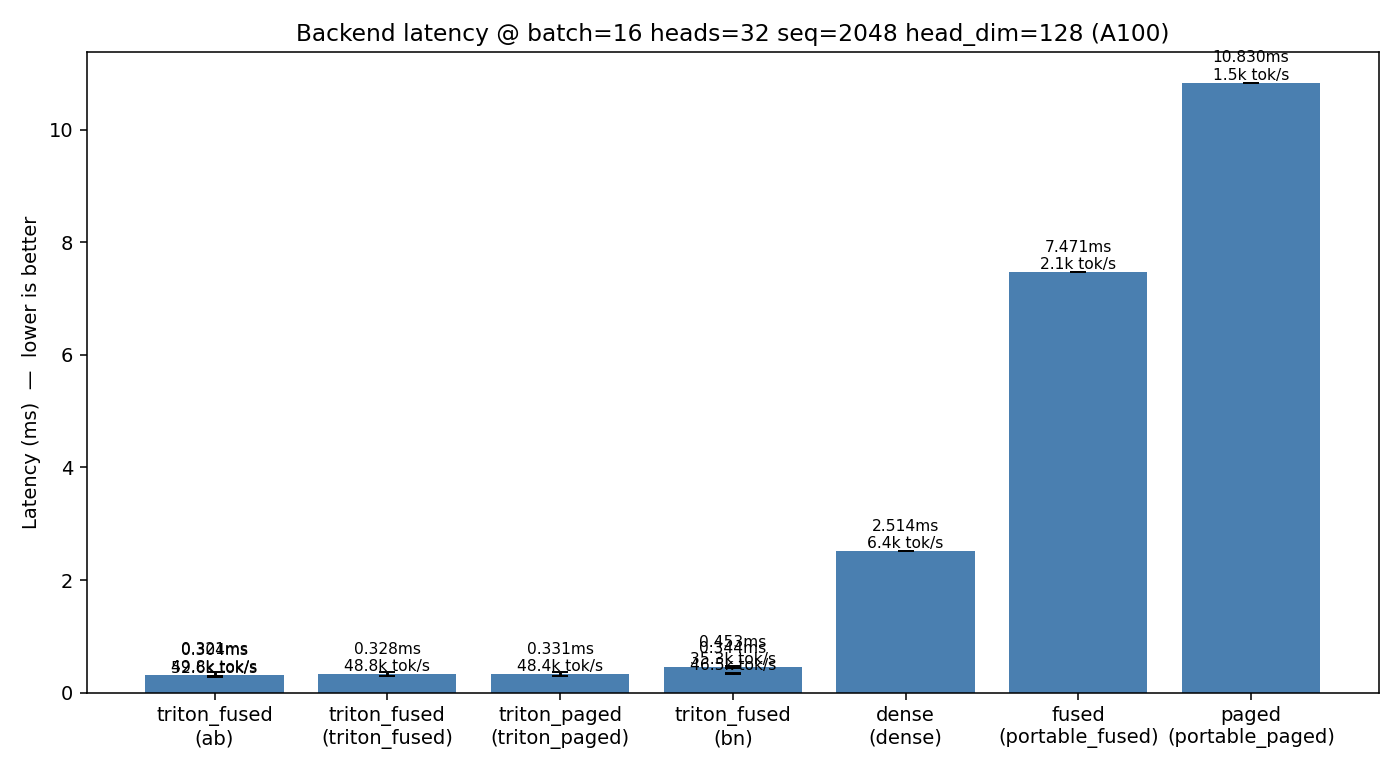

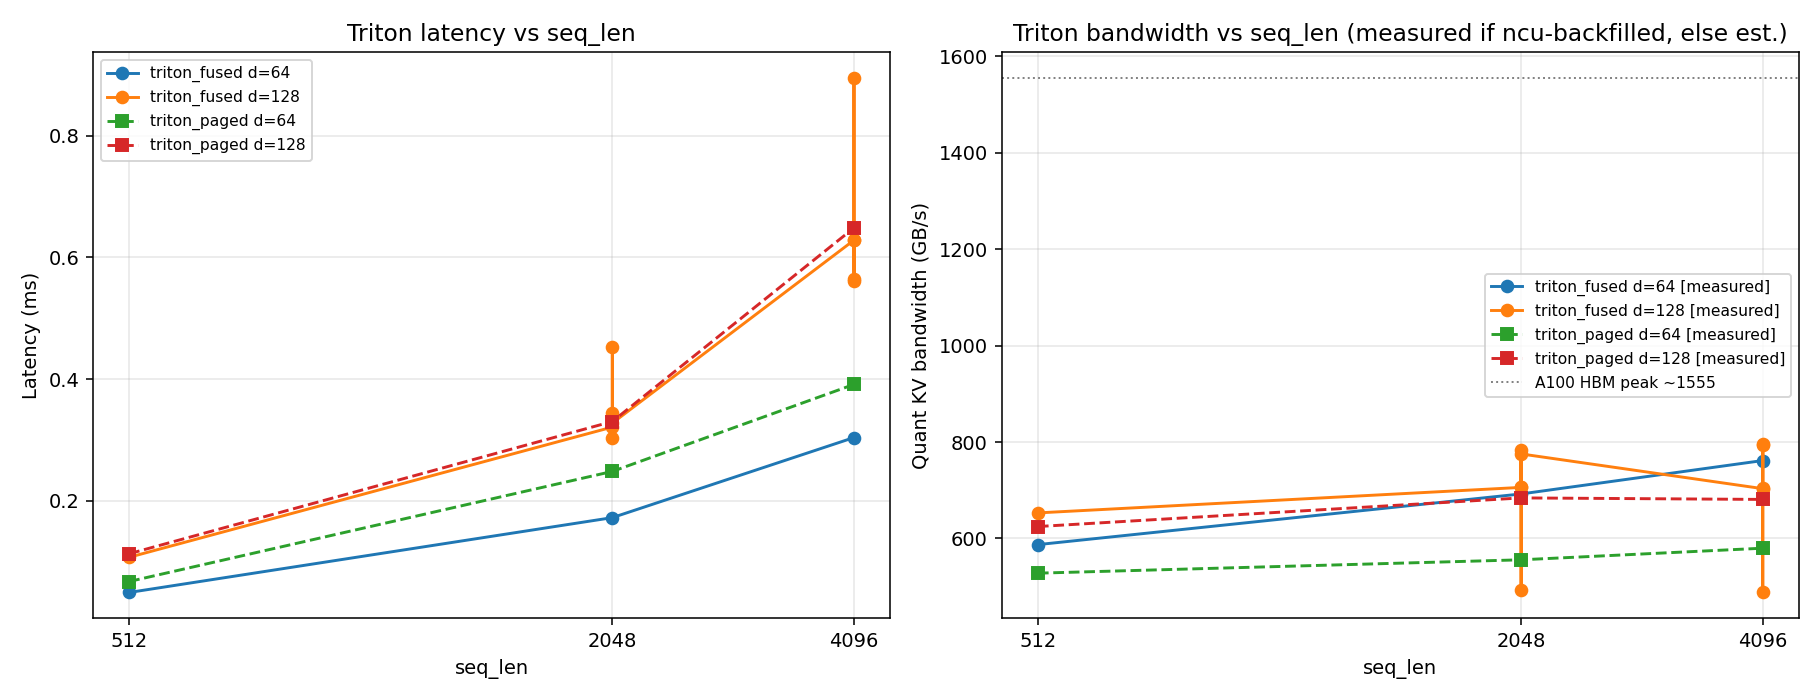

In [8]:
import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO = Path('/content/drive/MyDrive/FlashSpecColab')
COLAB_RESULTS_DIR = REPO / 'results' / 'colab_kernels'
MATRIX_RESULTS_DIR = REPO / 'results' / 'profile_matrix'
ANALYSIS_DIR = COLAB_RESULTS_DIR / 'analysis'
os.chdir(REPO)

!python scripts/analyze_results.py --results-dir "{COLAB_RESULTS_DIR}" --output-dir "{ANALYSIS_DIR}"

summary = ANALYSIS_DIR / 'summary.csv'
if summary.exists():
    display(pd.read_csv(summary).head(30))

for manifest in sorted(MATRIX_RESULTS_DIR.glob('**/*_manifest.csv')):
    print('\nMANIFEST:', manifest)
    df = pd.read_csv(manifest)
    display(df.head(30))

for png in ['backend_comparison_s2048_d128.png', 'triton_scaling.png']:
    p = ANALYSIS_DIR / png
    if p.exists():
        display(Image(filename=str(p)))

## 8. Next Step: Source-Line / Instruction Attribution

Based on the full matrix fast-metrics attribution in `doc/optimization-log.md`, do not expand the matrix next. Run a small set of attribution reports that explain the observed deltas.

Questions to answer:

- why `block_n=32` is slower even with higher occupancy;
- why `num_warps=8` does not help;
- whether the paged-vs-fused gap comes from block table indirection, address math, coalescing/cache behavior, or long scoreboard stalls;
- where the s2048 paged shuffled slowdown appears.

The cell below exports `.ncu-rep` files to `results/ncu_source_attribution/`. Inspect `SourceCounters / InstructionStats / MemoryWorkloadAnalysis / SchedulerStats`.


In [ ]:
import os
import subprocess
import sys
from pathlib import Path

REPO = Path('/content/drive/MyDrive/FlashSpecColab')
SOURCE_NCU_DIR = REPO / 'results' / 'ncu_source_attribution'
os.chdir(REPO)
SOURCE_NCU_DIR.mkdir(parents=True, exist_ok=True)

NCU_BIN = os.environ.get('NCU_BIN', 'ncu')
NCU_SECTIONS = ['SourceCounters', 'InstructionStats', 'MemoryWorkloadAnalysis', 'SchedulerStats']
KERNEL_REGEX = {
    'triton_fused': 'fused_dequant_attention|combine_splits',
    'triton_paged': 'paged_quant_attention_kernel|combine_splits',
}

COMMON_BENCH = [
    '--batch', '16', '--heads', '32', '--head-dim', '128', '--block-size', '16',
    '--iters', '50', '--warmup', '10', '--repeats', '1',
    '--device', 'cuda', '--dtype', 'float16', '--seed', '0', '--json',
]

# Five attribution categories from the optimization log. The slow-warps category runs both split=1 and split=4.
SOURCE_CASES = [
    dict(name='fused_best_s2048_d128_bn128_nw4_split4', backend='triton_fused', seq_len=2048, block_n=128, num_warps=4, num_splits=4, length_pattern='uniform', paged_layout='contiguous', launch_count=2),
    dict(name='fused_slow_tile_s2048_d128_bn32_nw4_split4', backend='triton_fused', seq_len=2048, block_n=32, num_warps=4, num_splits=4, length_pattern='uniform', paged_layout='contiguous', launch_count=2),
    dict(name='fused_slow_warps_s2048_d128_bn128_nw8_split1', backend='triton_fused', seq_len=2048, block_n=128, num_warps=8, num_splits=1, length_pattern='uniform', paged_layout='contiguous', launch_count=1),
    dict(name='fused_slow_warps_s2048_d128_bn128_nw8_split4', backend='triton_fused', seq_len=2048, block_n=128, num_warps=8, num_splits=4, length_pattern='uniform', paged_layout='contiguous', launch_count=2),
    dict(name='paged_best_s2048_d128_bn128_nw4_uniform_contiguous', backend='triton_paged', seq_len=2048, block_n=128, num_warps=4, num_splits=None, length_pattern='uniform', paged_layout='contiguous', launch_count=1),
    dict(name='paged_locality_slow_s2048_d128_bn128_nw4_uniform_shuffled', backend='triton_paged', seq_len=2048, block_n=128, num_warps=4, num_splits=None, length_pattern='uniform', paged_layout='shuffled', launch_count=1),
]

RUN_SOURCE_NCU = True  # Set to False to print commands only.

for case in SOURCE_CASES:
    env = os.environ.copy()
    env['FLASHSPEC_BLOCK_N'] = str(case['block_n'])
    env['FLASHSPEC_NUM_WARPS'] = str(case['num_warps'])
    if case['num_splits'] is None:
        env.pop('FLASHSPEC_NUM_SPLITS', None)
    else:
        env['FLASHSPEC_NUM_SPLITS'] = str(case['num_splits'])

    export_path = SOURCE_NCU_DIR / case['name']
    cmd = [NCU_BIN]
    for section in NCU_SECTIONS:
        cmd += ['--section', section]
    cmd += [
        '--kernel-name', f"regex:{KERNEL_REGEX[case['backend']]}",
        '--launch-count', str(case['launch_count']),
        '--target-processes', 'all',
        '--export', str(export_path),
        '--force-overwrite',
        sys.executable, 'benchmarks/microbench.py',
        '--backend', case['backend'],
        '--seq-len', str(case['seq_len']),
        '--length-pattern', case['length_pattern'],
        '--paged-layout', case['paged_layout'],
        '--layout-seed', '0',
    ] + COMMON_BENCH

    print('\nCASE:', case['name'])
    print('ENV:', ' '.join(f'{k}={env[k]}' for k in ['FLASHSPEC_BLOCK_N', 'FLASHSPEC_NUM_WARPS'] if k in env),
          f"FLASHSPEC_NUM_SPLITS={env.get('FLASHSPEC_NUM_SPLITS', 'unset')}")
    print('>>', ' '.join(cmd))
    if RUN_SOURCE_NCU:
        subprocess.run(cmd, env=env, check=True)

print('\nsource attribution reports:')
for rep in sorted(SOURCE_NCU_DIR.glob('*.ncu-rep')):
    print(rep)
